# Bosonic SDK walkthrough

This notebook is a source-level walkthrough of the Bosonic SDK installed in this repository's `.venv`. It explains the package layout, the internal circuit model, Qiskit conversion, distribution/transpilation, simulation, metrics, and how the workshop notebook uses the SDK.

The key package versions in this environment are:

| package | installed version | role |
|---|---:|---|
| `bosonic-sdk` | `0.1.5` | public SDK facade, distributors, simulator, metrics |
| `bosonic-model` | `0.1.1` | Pydantic circuit/instruction data model |
| `bosonic-converters` | `0.1.0` | Qiskit <-> Bosonic model conversion and remote-link gates |
| `bosonic-disqco` | `0.0.7` | optional DISQCO partitioning backend, installed here |
| `hypergraph-partitioner` | `0.1.1` | optional hypergraph partitioning backend, installed here |
| `qiskit` | `2.4.1` | circuit frontend and transpiler |
| `qiskit-aer` | `0.17.2` | simulator backend used by `bosonic_sdk.Simulator` |

The high-level flow used by the workshop is:

```text
Qiskit QuantumCircuit
  -> CircuitConverters.from_qiskit
  -> bosonic_model.Circuit
  -> bosonic_sdk.BosonicDistributor.distribute
  -> bosonic_model.DistributedCircuit
  -> DistributedCircuit.as_monolithic_circuit
  -> CircuitConverters.to_qiskit
  -> Qiskit QuantumCircuit with data qubits, communication qubits, remote-link gates, and feed-forward
```


## Setup

This first cell imports the packages we will use. The `MPLCONFIGDIR` line avoids a harmless Matplotlib cache warning on machines where the home directory cache is not writable.

In [37]:
import os
import tempfile
from importlib import metadata, import_module, util
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", tempfile.gettempdir())

import pandas as pd
import qiskit
import bosonic_sdk
from bosonic_converters import CircuitConverters


In [38]:
packages = [
    "bosonic-sdk",
    "bosonic-model",
    "bosonic-converters",
    "bosonic-disqco",
    "hypergraph-partitioner",
    "qiskit",
    "qiskit-aer",
]

pd.DataFrame(
    [{"package": name, "version": metadata.version(name)} for name in packages]
)


,package,version
0,bosonic-sdk,0.1.5
1,bosonic-model,0.1.1
2,bosonic-converters,0.1.0
3,bosonic-disqco,0.0.7
4,hypergraph-partitioner,0.1.1
5,qiskit,2.4.1
6,qiskit-aer,0.17.2


## Package map

The SDK is split into three top-level import packages:

| module | responsibility |
|---|---|
| `bosonic_sdk` | public API, distributors, statistics, simulator |
| `bosonic_model` | internal circuit representation: registers, instructions, distributed circuits |
| `bosonic_converters` | conversion to/from Qiskit and Qiskit custom remote-link gates |

The public API exported by `bosonic_sdk.__init__` is intentionally small:

- `BosonicDistributor`
- `DisqcoDistributor`
- `PytketDistributor`
- `GateStatistics`, `GateStats`
- `Simulator`


In [39]:
for module_name in ["bosonic_sdk", "bosonic_model", "bosonic_converters"]:
    module = import_module(module_name)
    exported = [name for name in dir(module) if not name.startswith("_")]
    print(module_name)
    print("  file:", module.__file__)
    print("  exports:", exported[:30], "..." if len(exported) > 30 else "")


bosonic_sdk
  file: /Users/felixvelasquez/dqc-workshop-notebook/.venv/lib/python3.10/site-packages/bosonic_sdk/__init__.py
  exports: ['BosonicDistributor', 'DisqcoDistributor', 'GateStatistics', 'GateStats', 'PytketDistributor', 'Simulator', 'distributor', 'gate_statistics', 'simulation'] 
bosonic_model
  file: /Users/felixvelasquez/dqc-workshop-notebook/.venv/lib/python3.10/site-packages/bosonic_model/__init__.py
  exports: ['Annotated', 'BarrierInstruction', 'BaseModel', 'BinaryExpr', 'C3sqrtxInstruction', 'C3xInstruction', 'C4xInstruction', 'CcxInstruction', 'ChInstruction', 'Circuit', 'ClassicalInstruction', 'Condition', 'ConditionalInstruction', 'ConstExpr', 'CpInstruction', 'CrxInstruction', 'CryInstruction', 'CrzInstruction', 'CswapInstruction', 'CsxInstruction', 'Cu1Instruction', 'Cu3Instruction', 'CuInstruction', 'CxInstruction', 'CyInstruction', 'CzInstruction', 'DistributedCircuit', 'Expr', 'Field', 'FuncExpr'] ...
bosonic_converters
  file: /Users/felixvelasquez/dqc-worksh

## The internal circuit model

`bosonic_model` is a small Pydantic data model. It exists because Qiskit does not directly model distributed quantum programs with per-node subcircuits and cross-node communication primitives.

The central classes are:

| class | meaning |
|---|---|
| `Register` | named register with `size` and global `base` offset |
| `Circuit` | dictionaries of quantum/classical registers plus an ordered list of instructions |
| `Instruction` subclasses | strongly typed operations such as `UInstruction`, `CxInstruction`, `MeasureInstruction`, `ConditionalInstruction` |
| `DistributedCircuit` | node-local `Circuit` objects plus `qubits_per_node` mapping |

`Circuit.qubits()` returns the total number of quantum bits by summing quantum register sizes. Instructions also carry a `qubits` list, which is what distribution and statistics code uses for locality and depth.

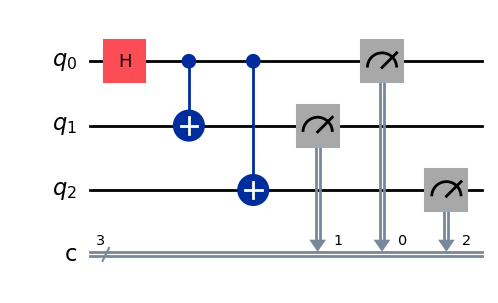

In [ ]:
def ghz_circuit(n: int, measure: bool = True) -> qiskit.QuantumCircuit:
    qc = qiskit.QuantumCircuit(n, n)
    qc.h(0)
    for i in range(1, n):
        qc.cx(0, i)
    if measure:
        qc.measure(range(n), range(n))
    return qc

logical_qc = ghz_circuit(3)
logical_qc.draw("mpl")


In [41]:
model_circuit = CircuitConverters.from_qiskit(logical_qc)

print("qregs:", model_circuit.qregs)
print("cregs:", model_circuit.cregs)
print("qubit count:", model_circuit.qubits())

def instruction_row(i, inst):
    return {
        "i": i,
        "type": type(inst).__name__,
        "kind": getattr(inst, "kind", None),
        "name": getattr(inst, "name", None),
        "qubits": getattr(inst, "qubits", None),
        "params": getattr(inst, "params", None),
        "condition": getattr(inst, "condition", None),
    }

pd.DataFrame(instruction_row(i, inst) for i, inst in enumerate(model_circuit.instructions))


qregs: {'q': Register(name='q', size=3, base=0)}
cregs: {'c': Register(name='c', size=3, base=0)}
qubit count: 3


,i,type,kind,name,qubits,params,condition
0,0,HInstruction,h,h,[0],[],None
1,1,CxInstruction,cx,cx,"[0, 1]",[],None
2,2,CxInstruction,cx,cx,"[0, 2]",[],None
3,3,MeasureInstruction,measure,None,[0],None,None
4,4,MeasureInstruction,measure,None,[1],None,None
5,5,MeasureInstruction,measure,None,[2],None,None


## Qiskit conversion

`CircuitConverters.from_qiskit` does four main things:

1. Converts Qiskit quantum/classical registers into `Register(name, size, base)` records.
2. Builds global qubit and classical-bit index maps.
3. Converts common Qiskit operations into typed Bosonic instructions.
4. Preserves `if_else` or conditional operations as `ConditionalInstruction` when possible.

`CircuitConverters.to_qiskit` reverses that process. It also knows how to emit the SDK's custom remote-link gates:

- `RemoteLinkGatePsiMinus`
- `RemoteLinkGatePsiPlus`
- `RemoteLinkGatePhiPlus`

These are Qiskit `Gate` subclasses with explicit matrices, so Aer can simulate them after the SDK's simulator replaces them with `UnitaryGate` objects.

In [42]:
round_trip = CircuitConverters.to_qiskit(model_circuit)
print(round_trip)
print("ops:", round_trip.count_ops())


     ┌───┐             ┌─┐   
q_0: ┤ H ├──■────■─────┤M├───
     └───┘┌─┴─┐  │  ┌─┐└╥┘   
q_1: ─────┤ X ├──┼──┤M├─╫────
          └───┘┌─┴─┐└╥┘ ║ ┌─┐
q_2: ──────────┤ X ├─╫──╫─┤M├
               └───┘ ║  ║ └╥┘
c: 3/════════════════╩══╩══╩═
                     1  0  2 
ops: OrderedDict([('measure', 3), ('cx', 2), ('h', 1)])


## Distributor contract

All distributor classes implement the same interface:

```python
distribute(
    circ: bosonic_model.Circuit,
    nodes: int,
    qubits_per_node: int,
    lowered: bool = False,
) -> bosonic_model.DistributedCircuit
```

The base class also has `distribute_with_timeout(...)`, which runs `distribute` in a subprocess and raises `concurrent.futures.TimeoutError` if it takes too long.

For `BosonicDistributor`, `lowered` is currently accepted but not used: the output is always the lowered Bosonic remote-link protocol. For `DisqcoDistributor` and `HypergraphDistributor`, `lowered` changes whether the output is symbolic or expanded into lower-level communication primitives.

## `BosonicDistributor`: compiler pipeline

`BosonicDistributor` is the path used by the workshop notebook. Its `distribute` method performs this pipeline:

1. `_strip_barriers`: remove barriers because they are not part of the hardware operation model.
2. `_transpile_circuit_to_basis`: use Qiskit `transpile` to reduce the circuit to `u`, `cx`, measurement/reset/delay/control-flow operations. It uses trivial layout, no routing, and optimization level 3.
3. `_map_circuit_to_hardware`: double the quantum register size. Logical data qubit `i` maps to physical qubit `2*i`, and its communication qubit maps to `2*i + 1`.
4. `_decompose_cx`: replace each `cx` with local hardware-basis operations or with the remote-link protocol if the endpoints live on different nodes.
5. `_verify_bosonic_circuit`: assert the result only contains allowed operations and obeys locality rules.
6. `_as_distributed_circuit`: split the monolithic physical circuit into per-node circuits.

The important mental model: `qubits_per_node` is the number of logical ions/data positions per node. After hardware mapping, each node can contain twice that many physical qubits because every data qubit gets a paired communication qubit.

In [43]:
distributor = bosonic_sdk.BosonicDistributor()
distributed = distributor.distribute(
    model_circuit,
    nodes=2,
    qubits_per_node=2,
    lowered=True,
)

print("qubits_per_node map:", distributed.qubits_per_node)
print("instructions per node:", {node: len(c.instructions) for node, c in distributed.circuits.items()})
print("remote coupling map:", distributed.coupling_map())


qubits_per_node map: {0: [0, 1, 2, 3], 1: [4, 5]}
instructions per node: {0: 16, 1: 10}
remote coupling map: {(0, 1): 1}


compiled qubits: 6
compiled classical bits: 4
Qiskit ops: OrderedDict([('u', 14), ('measure', 4), ('rzz', 3), ('reset', 2), ('remote_link_psi_minus', 1), ('if_else', 1)])
Qiskit depth: 12


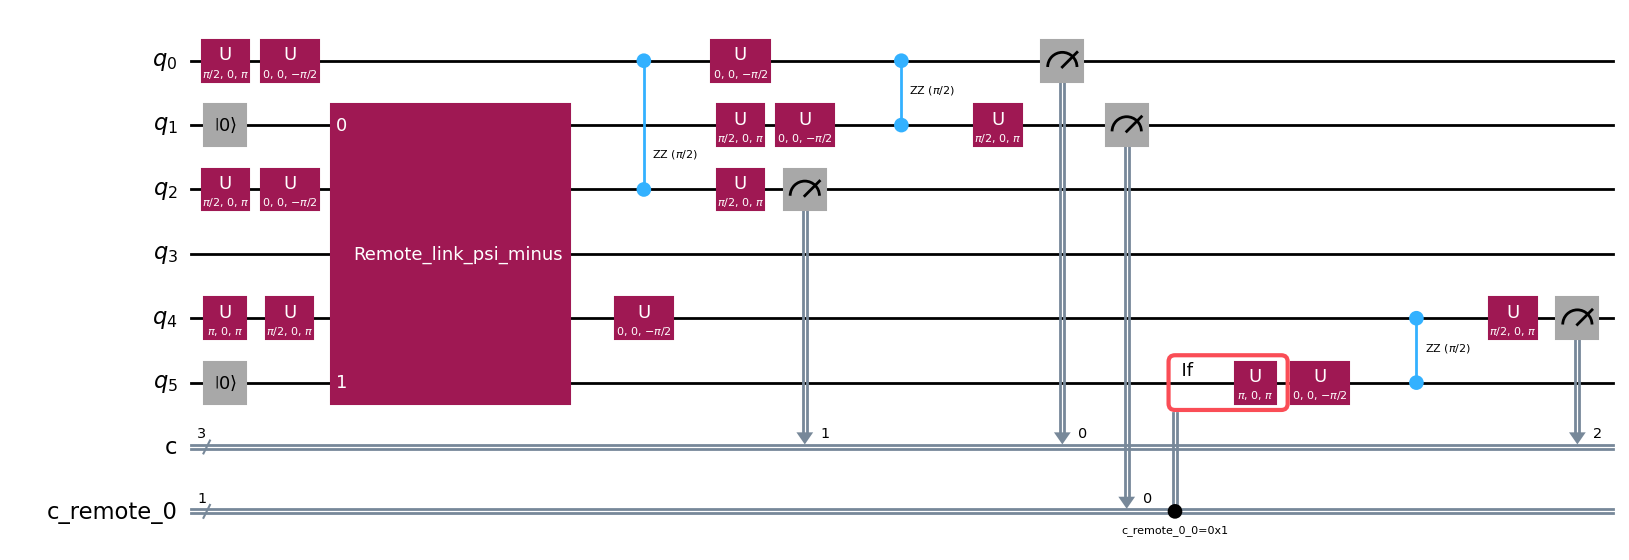

In [56]:
compiled_model = distributed.as_monolithic_circuit()
compiled_qiskit = CircuitConverters.to_qiskit(compiled_model)

print("compiled qubits:", compiled_qiskit.num_qubits)
print("compiled classical bits:", compiled_qiskit.num_clbits)
print("Qiskit ops:", compiled_qiskit.count_ops())
print("Qiskit depth:", compiled_qiskit.depth())

compiled_qiskit.draw("mpl")


## Logical CNOT example

Here is the smallest example that forces the SDK to use the distributed remote-link protocol: a logical `cx(0, 1)` placed across two modules with one logical data qubit per module.

The mapping will be:

- logical qubit `0` -> physical data qubit `0`, with communication qubit `1`
- logical qubit `1` -> physical data qubit `2`, with communication qubit `3`


Logical CNOT


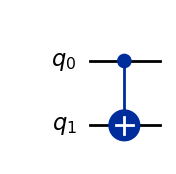


Bosonic SDK transpiled CNOT


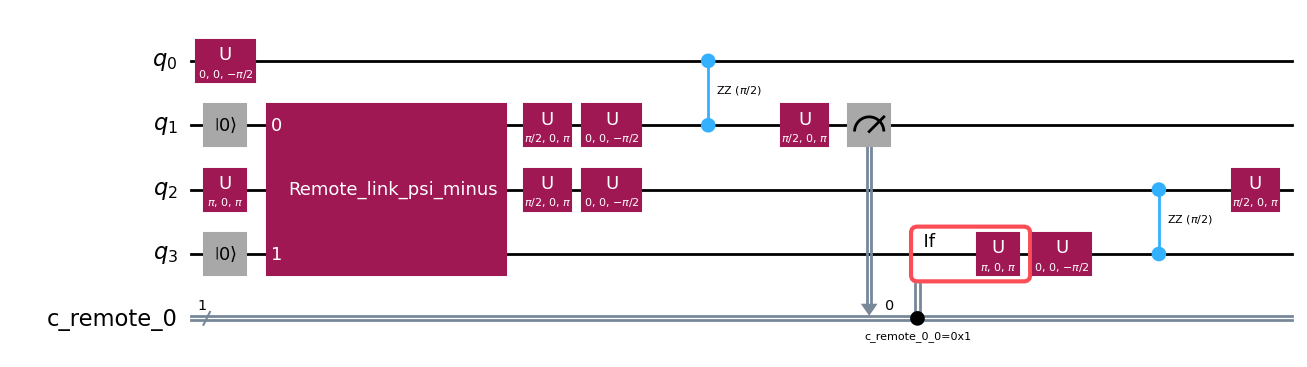


qubits_per_node: {0: [0, 1], 1: [2, 3]}
ops: {'u': 9, 'reset': 2, 'rzz': 2, 'remote_link_psi_minus': 1, 'measure': 1, 'if_else': 1}
depth: 11


In [45]:
from IPython.display import display

logical_cnot = qiskit.QuantumCircuit(2, name="logical_cnot")
logical_cnot.cx(0, 1)

print("Logical CNOT")
display(logical_cnot.draw(output="mpl"))

cnot_distributed = bosonic_sdk.BosonicDistributor().distribute(
    CircuitConverters.from_qiskit(logical_cnot),
    nodes=2,
    qubits_per_node=1,
    lowered=True,
)
cnot_model = cnot_distributed.as_monolithic_circuit()
cnot_transpiled = CircuitConverters.to_qiskit(cnot_model)

print("\nBosonic SDK transpiled CNOT")
display(cnot_transpiled.draw(output="mpl", fold=-1))
print("\nqubits_per_node:", cnot_distributed.qubits_per_node)
print("ops:", dict(cnot_transpiled.count_ops()))
print("depth:", cnot_transpiled.depth())


In [46]:
def cnot_instruction_row(i, inst):
    inner = getattr(inst, "op", inst)
    return {
        "i": i,
        "type": type(inst).__name__,
        "inner_type": type(inner).__name__,
        "name": getattr(inner, "name", getattr(inner, "kind", None)),
        "qubits": getattr(inst, "qubits", getattr(inner, "qubits", None)),
        "condition": getattr(inst, "condition", None),
    }

pd.DataFrame(
    cnot_instruction_row(i, inst) for i, inst in enumerate(cnot_model.instructions)
)


,i,type,inner_type,name,qubits,condition
0,0,ResetInstruction,ResetInstruction,reset,[1],None
1,1,ResetInstruction,ResetInstruction,reset,[3],None
2,2,GateInstruction,GateInstruction,remote_link_psi_minus,"[1, 3]",None
3,3,UInstruction,UInstruction,u,[1],None
4,4,UInstruction,UInstruction,u,[0],None
5,5,UInstruction,UInstruction,u,[1],None
6,6,RzzInstruction,RzzInstruction,rzz,"[0, 1]",None
7,7,UInstruction,UInstruction,u,[1],None
8,8,MeasureInstruction,MeasureInstruction,measure,[1],None
9,9,ConditionalInstruction,UInstruction,u,[3],cbit=0 value=True


## How `cx` is lowered

The SDK has two cases for a `cx` after hardware mapping:

### Same node

A local `cx(control, target)` is decomposed into the native basis:

```text
u(target, pi/2, 0, pi)
u(control, 0, 0, -pi/2)
u(target, 0, 0, -pi/2)
rzz(control, target, pi/2)
u(target, pi/2, 0, pi)
```

### Different nodes

A remote `cx(data_ctrl, data_tgt)` uses the communication qubits `comm_ctrl = data_ctrl + 1` and `comm_tgt = data_tgt + 1`:

```text
reset(comm_ctrl)
reset(comm_tgt)
remote_link_psi_minus(comm_ctrl, comm_tgt)
local cx(data_ctrl, comm_ctrl), lowered to u/rzz/u
measure(comm_ctrl -> c_remote_N)
if c_remote_N: x(comm_tgt), lowered to u(pi, 0, pi)
x(data_tgt), lowered to u(pi, 0, pi)
local cx(comm_tgt, data_tgt), lowered to u/rzz/u
```

Each remote interaction introduces one remote classical bit named `c_remote_N`.

In [47]:
def summarize_inst(i, inst):
    inner = getattr(inst, "op", inst)
    return {
        "i": i,
        "type": type(inst).__name__,
        "inner_type": type(inner).__name__,
        "name": getattr(inner, "name", getattr(inner, "kind", None)),
        "qubits": getattr(inst, "qubits", getattr(inner, "qubits", None)),
        "condition": getattr(inst, "condition", None),
    }

pd.DataFrame(
    summarize_inst(i, inst) for i, inst in enumerate(compiled_model.instructions)
)


,i,type,inner_type,name,qubits,condition
0,0,UInstruction,UInstruction,u,[0],None
1,1,UInstruction,UInstruction,u,[2],None
2,2,UInstruction,UInstruction,u,[0],None
3,3,UInstruction,UInstruction,u,[2],None
4,4,RzzInstruction,RzzInstruction,rzz,"[0, 2]",None
5,5,UInstruction,UInstruction,u,[2],None
6,6,ResetInstruction,ResetInstruction,reset,[1],None
7,7,ResetInstruction,ResetInstruction,reset,[5],None
8,8,GateInstruction,GateInstruction,remote_link_psi_minus,"[1, 5]",None
9,9,UInstruction,UInstruction,u,[1],None


## `DistributedCircuit`

`DistributedCircuit` stores:

- `qubits_per_node`: a dictionary like `{0: [0, 1, 2, 3], 1: [4, 5]}`.
- `circuits`: one node-local `Circuit` per node.
- `_instruction_index`: private ordering metadata used when flattening back to a monolithic circuit.

It validates locality at construction time: normal instructions must only touch qubits assigned to that node. Remote instructions are allowed to appear in multiple node-local circuits. `as_monolithic_circuit()` flattens the node-local circuits back into one ordered `Circuit`, de-duplicating shared remote instructions.

In [48]:
for node, node_circuit in distributed.circuits.items():
    print(f"node {node}: allowed qubits {distributed.qubits_per_node[node]}")
    print("  first few ops:")
    for inst in node_circuit.instructions[:8]:
        inner = getattr(inst, "op", inst)
        print("   ", getattr(inner, "name", getattr(inner, "kind", None)), getattr(inst, "qubits", None))


node 0: allowed qubits [0, 1, 2, 3]
  first few ops:
    u [0]
    u [2]
    u [0]
    u [2]
    rzz [0, 2]
    u [2]
    reset [1]
    remote_link_psi_minus [1, 5]
node 1: allowed qubits [4, 5]
  first few ops:
    reset [5]
    remote_link_psi_minus [1, 5]
    u [5]
    u [4]
    u [4]
    u [5]
    u [4]
    rzz [5, 4]


## Remote-link gates and simulation

`bosonic_converters.remote_link` defines three Qiskit gates with matrices:

- `remote_link_psi_minus`
- `remote_link_psi_plus`
- `remote_link_phi_plus`

`bosonic_sdk.Simulator` is currently a wrapper around Qiskit Aer. It repeatedly decomposes the circuit, replaces remote-link gate objects with matrix-backed `UnitaryGate` objects, and runs `AerSimulator(method="matrix_product_state")`.

`ignore_c_remote=True` marginalizes away the remote-protocol classical bits so the returned counts correspond to the user-facing measurement register. The simulator first looks for a classical register named `verify_0`, then for one named `c`.

In [49]:
counts, clbits = bosonic_sdk.Simulator().run_counts(
    compiled_qiskit,
    ignore_c_remote=True,
    shots=256,
)

print("kept classical bits:", clbits)
print(counts)


kept classical bits: 3
{'111': 135, '000': 121}


## Gate statistics

`GateStatistics.stats` accepts either a `bosonic_model.Circuit` or a `DistributedCircuit`. For distributed circuits it first calls `as_monolithic_circuit()`.

Important details:

- `measure`, `reset`, `barrier`, and `ClassicalInstruction` are counted separately and excluded from `total_ops`.
- `ConditionalInstruction` is unwrapped for gate counting and depth.
- `remote_gate_count` counts gate names that start with `remote_`.
- `qubit_teleportation_count` counts names containing remote-link, remote-EPR, teleport, starting process, or ending process markers.
- The depth model is a simple instruction-layer calculation over qubits, not Qiskit's full scheduler.

This is why Qiskit's `count_ops()` and `GateStatistics.stats()` can differ around `if_else`: Qiskit counts the control-flow wrapper, while `GateStatistics` counts the instruction inside the conditional.

In [50]:
bosonic_sdk.GateStatistics.stats(compiled_model)


{'n_qubits': 6,
 'n_clbits': 4,
 'total_ops': 19,
 'depth': 7,
 'gate_counts': {'u': 15, 'rzz': 3, 'remote_link_psi_minus': 1},
 'basis_gates': ['remote_link_psi_minus', 'rzz', 'u'],
 'measure_count': 4,
 'reset_count': 2,
 'barrier_count': 0,
 'local_gate_count': 18,
 'remote_gate_count': 1,
 'total_remote_gates': 1,
 'qubit_teleportation_count': 1,
 'n_classical_gates': 0}

## Other distributor backends

The SDK exposes more distributor implementations. They share the same return type but use different partitioning strategies.

| distributor | installed here? | approach |
|---|---:|---|
| `BosonicDistributor` | yes | direct physical lowering with data/communication qubit pairs and remote-link gates |
| `DisqcoDistributor` | yes | converts to a DISQCO hypergraph/network problem, partitions qubits, optionally extracts a lowered partitioned circuit |
| `HypergraphDistributor` | yes | delegates to `hypergraph_partitioner.partition_circuit`, which segments, partitions, annotates, and optionally lowers |
| `PytketDistributor` | no | requires `bosonic-sdk[pytket-dqc]`; converts through QASM/pytket and uses pytket-dqc hypergraph allocation |


In [51]:
optional_modules = ["disqco", "hypergraph_partitioner", "pytket", "pytket_dqc"]
pd.DataFrame(
    [{"module": name, "available": util.find_spec(name) is not None} for name in optional_modules]
)


,module,available
0,disqco,True
1,hypergraph_partitioner,True
2,pytket,False
3,pytket_dqc,False


### `DisqcoDistributor`

`DisqcoDistributor` is a wrapper around the installed `disqco` package. Its flow is:

1. `_normalize_for_disqco`: drop measurements, resets, barriers, delays, and classical control; keep only unitary operations, then transpile to `u`, `cp`, `cx`.
2. Build an all-to-all `QuantumNetwork` with `nodes` modules and `qubits_per_node` capacity.
3. Build a `QuantumCircuitHyperGraph` and run the Fiduccia-Mattheyses multilevel partitioner.
4. If `lowered=False`, require a static qubit-to-node assignment and build a symbolic `DistributedCircuit`.
5. If `lowered=True`, ask DISQCO to extract a partitioned Qiskit circuit, inline DISQCO wrapper gates while preserving classical conditions, convert back to the Bosonic model, infer nodes from Qiskit register names, and build a distributed circuit.

Cross-node operations become gates whose names are prefixed with `remote_`, unless they already start with `remote_`.

In [52]:
# Template for experimenting with DISQCO. It can be slower than BosonicDistributor.
# from bosonic_sdk import DisqcoDistributor
# disqco_distributed = DisqcoDistributor(num_passes=3).distribute(
#     model_circuit,
#     nodes=2,
#     qubits_per_node=2,
#     lowered=False,
# )
# disqco_distributed.qubits_per_node


### `HypergraphDistributor`

`HypergraphDistributor` is a thin wrapper over `hypergraph_partitioner.partition_circuit(...)`.

That partitioner pipeline:

1. Normalizes the circuit to one-qubit gates and `cz` interactions.
2. Pushes `cz` operations earlier where possible.
3. Splits the instruction stream into interaction-based segments.
4. Builds a hypergraph where qubits and interactions are vertices.
5. Runs the KaHyPar-based partitioner for each segment.
6. Merges segment boundaries using seam heuristics.
7. Annotates local operations, nonlocal CZ operations, and boundary teleports.
8. Returns either symbolic output or lowered output depending on `lowered`.

The SDK class exposes only two tunables as class attributes: `INIT_SEG_SIZE = 10` and `MAX_HEDGE_DIST = 100`.

In [53]:
# Template for experimenting with the hypergraph backend.
# from bosonic_sdk.distributor.distributors.hypergraph_distributor import HypergraphDistributor
# hypergraph_distributed = HypergraphDistributor().distribute(
#     model_circuit,
#     nodes=2,
#     qubits_per_node=2,
#     lowered=False,
# )
# hypergraph_distributed.qubits_per_node


### `PytketDistributor`

`PytketDistributor` is available in the SDK source, but its dependencies are not installed in this environment. It requires `bosonic-sdk[pytket-dqc]`.

Its flow is:

1. Strip barriers, measurements, resets, and classical instructions.
2. Convert Bosonic model -> Qiskit -> QASM2 -> pytket circuit.
3. Apply pytket-dqc's `DQCPass`.
4. Build an all-to-all `NISQNetwork`.
5. Use `HypergraphPartitioning().allocate(...)`.
6. Convert the compiled pytket circuit back to the Bosonic model through QASM.
7. Build a `DistributedCircuit`, prefixing cross-node gates with `remote_`.


## How the workshop notebook uses the SDK

The workshop's helper function is essentially:

```python
def compile_bosonic_circuit(circuit, n, modules, distributor):
    distributed = distributor.distribute(
        CircuitConverters.from_qiskit(circuit),
        nodes=int(modules),
        qubits_per_node=np.ceil(n / modules).astype(int),
        lowered=True,
    ).as_monolithic_circuit()
    return CircuitConverters.to_qiskit(distributed)
```

For `BosonicDistributor`, this means:

- `n` is the number of logical/data qubits in the original circuit.
- `modules` is the number of distributed QPU modules/traps.
- `ceil(n / modules)` is the logical/data capacity per module.
- The compiled Qiskit circuit has roughly `2*n` quantum wires because each data qubit gets a communication qubit.
- Remote protocol measurement bits are added as `c_remote_0`, `c_remote_1`, and so on.

The workshop then uses:

- `bosonic_sdk.Simulator().run_counts(..., ignore_c_remote=True)` for correctness checks.
- `bosonic_sdk.GateStatistics.stats(CircuitConverters.from_qiskit(circuit))` for comparable metrics.


In [54]:
def compile_bosonic_circuit(circuit, n, modules, distributor=None):
    if distributor is None:
        distributor = bosonic_sdk.BosonicDistributor()
    distributed = distributor.distribute(
        CircuitConverters.from_qiskit(circuit),
        nodes=int(modules),
        qubits_per_node=int(-(-n // modules)),  # integer ceil(n / modules)
        lowered=True,
    ).as_monolithic_circuit()
    return CircuitConverters.to_qiskit(distributed)

compiled = compile_bosonic_circuit(ghz_circuit(5), n=5, modules=2)
print("qubits:", compiled.num_qubits)
print("classical bits:", compiled.num_clbits)
print("ops:", compiled.count_ops())


qubits: 10
classical bits: 7
ops: OrderedDict([('u', 27), ('measure', 7), ('rzz', 6), ('reset', 4), ('remote_link_psi_minus', 2), ('if_else', 2)])


## Practical gotchas

- `BosonicDistributor.distribute` expects a `bosonic_model.Circuit`, not a Qiskit `QuantumCircuit`. Use `CircuitConverters.from_qiskit` first.
- `CircuitConverters.to_qiskit` expects a monolithic `Circuit`, so call `distributed.as_monolithic_circuit()` when starting from a `DistributedCircuit`.
- `BosonicDistributor` doubles the quantum register. Even physical qubits are data qubits; odd physical qubits are communication qubits.
- `qubits_per_node` is interpreted before doubling. A node with `qubits_per_node=32` can have 32 data qubits plus 32 communication qubits in the physical circuit.
- `GateStatistics.depth` is a lightweight layer model. It is useful for consistent comparisons inside this SDK, but it is not the same as backend scheduling or Qiskit's hardware-aware duration estimates.
- `ignore_c_remote=True` only removes the remote protocol classical bits when the measured data register is named `verify_0` or `c`.
- The verifier in `BosonicDistributor` uses Python `assert` statements. Assertions can be disabled with optimized Python mode, so treat them as internal checks rather than user-facing validation errors.
- `lowered=True` matters for DISQCO and hypergraph distributors. It is accepted but effectively ignored by the direct `BosonicDistributor` path.


## Quick source index

Useful files inside the installed venv:

| file | what to read there |
|---|---|
| `.venv/lib/python3.10/site-packages/bosonic_sdk/__init__.py` | public API exports |
| `.venv/lib/python3.10/site-packages/bosonic_sdk/distributor/distributor.py` | base distributor contract and timeout wrapper |
| `.venv/lib/python3.10/site-packages/bosonic_sdk/distributor/distributors/bosonic_distributor.py` | direct Bosonic compiler/lowering pipeline |
| `.venv/lib/python3.10/site-packages/bosonic_sdk/distributor/distributors/disqco_distributor.py` | DISQCO integration |
| `.venv/lib/python3.10/site-packages/bosonic_sdk/distributor/distributors/hypergraph_distributor.py` | hypergraph wrapper |
| `.venv/lib/python3.10/site-packages/bosonic_sdk/distributor/distributors/pytket_distributor.py` | pytket-dqc wrapper |
| `.venv/lib/python3.10/site-packages/bosonic_sdk/gate_statistics.py` | metrics and depth model |
| `.venv/lib/python3.10/site-packages/bosonic_sdk/simulation/simulator.py` | Aer simulation wrapper |
| `.venv/lib/python3.10/site-packages/bosonic_model/circuit.py` | `Register` and `Circuit` |
| `.venv/lib/python3.10/site-packages/bosonic_model/distributed_circuit.py` | distributed circuit validation, flattening, coupling map |
| `.venv/lib/python3.10/site-packages/bosonic_model/instructions.py` | instruction schema |
| `.venv/lib/python3.10/site-packages/bosonic_converters/converters.py` | Qiskit conversion logic |
| `.venv/lib/python3.10/site-packages/bosonic_converters/remote_link.py` | remote-link Qiskit gates and matrices |
| `.venv/lib/python3.10/site-packages/hypergraph_partitioner/bosonic_pipeline.py` | hypergraph partitioning pipeline |

A good reading order is: public API -> model -> converters -> direct distributor -> simulator -> statistics -> optional distributors.